# Data Cleaning Walkthrough — IMDb Movies Dataset

**Dataset:** [Movies Dataset for Feature Extraction & Prediction](https://www.kaggle.com/datasets/bharatnatrayn/movies-dataset-for-feature-extracion-prediction) (Kaggle)

This notebook is a **learning-focused, end-to-end data cleaning project**. The raw file is a scrape of IMDb listings, and it is genuinely messy in the way real-world scraped data usually is:

- Stray `\n` newlines and trailing whitespace baked into almost every text field
- A `YEAR` column that mixes single years, year ranges, "ongoing series" markers, roman-numeral disambiguators (e.g. `(I)`, `(II)`), and tags like `TV Movie` / `Video`
- A `STARS` column that crams **director name(s) and cast** into a single blob of text
- `VOTES` and `Gross` stored as formatted strings (`"21,062"`, `"$75.47M"`) instead of numbers
- Heavy, *structurally meaningful* missingness (e.g. `Gross` is ~95% missing because most entries are TV shows, which don't report box-office gross)
- Exact duplicate rows, and "soft" duplicates (same title scraped twice with slightly different metadata)

### What this notebook teaches
Rather than just running `.dropna()` and calling it done, we'll walk through the *reasoning* behind each cleaning decision:

1. **Inspect before you touch anything** — understand shape, types, and missingness
2. **Clean column-by-column**, using regex to pull structured fields out of messy text
3. **Distinguish "missing because broken" from "missing because not applicable"**
4. **Make (and justify) explicit decisions** about dropping vs. imputing vs. leaving NaN
5. **Validate** the cleaned result against sanity checks
6. **Export** a clean, analysis-ready dataset

> 💡 Throughout, we keep the **original messy columns untouched** until the very end, and build new clean columns alongside them. This lets you compare before/after at every step — a good habit for any cleaning project.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# Display options so we can actually see the messy text in full
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', None)

plt.rcParams['figure.dpi'] = 100


## 2. Load the data and take a first look

Always start by loading the raw file **without modifying anything**. The goal here is purely
to understand what we're working with: how big is it, what columns exist, what are the dtypes,
and — critically — what does the *raw* text actually look like (not just `.head()`, which can
hide newline/whitespace problems).

In [2]:
df_raw = pd.read_csv('movies.csv')
print(f"Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()


Shape: 9999 rows, 9 columns


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlant...,"\n Director:\nPeter Thorwarth\n| \n Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Set...","21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated serie...,"\n \n Stars:\nChris Wood, \nSarah Michelle Gellar, \nLena Headey, \nMark Hamill\n","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors ...,"\n \n Stars:\nAndrew Lincoln, \nNorman Reedus, \nMelissa McBride, \nLauren Cohan\n","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits of a super scientist and his not-so-bright grandson.,"\n \n Stars:\nJustin Roiland, \nChris Parnell, \nSpencer Grammer, \nSarah Chalke\n","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a ...","\n Director:\nMatthias Schweighöfer\n| \n Stars:\nMatthias Schweighöfer, \nNathalie Emmanuel, \nRuby O. Fee, \...",NaN,NaN,NaN


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [4]:
# .head() hides whitespace/newline issues because the display truncates them.
# repr() reveals the raw string — this is how you should always inspect text columns
# in a dataset you suspect is dirty.
print("GENRE, raw repr:")
print(repr(df_raw['GENRE'].iloc[0]))
print()
print("STARS, raw repr:")
print(repr(df_raw['STARS'].iloc[4]))
print()
print("YEAR, raw repr:")
print(repr(df_raw['YEAR'].iloc[1]))


GENRE, raw repr:
'\nAction, Horror, Thriller            '

STARS, raw repr:
'\n    Director:\nMatthias Schweighöfer\n| \n    Stars:\nMatthias Schweighöfer, \nNathalie Emmanuel, \nRuby O. Fee, \nStuart Martin\n'

YEAR, raw repr:
'(2021– )'


**Observation:** every text field is wrapped in stray `\n` characters and inconsistent trailing
spaces — almost certainly an artifact of scraping HTML where each value sat inside its own `<td>`
or `<span>` tag. `STARS` is the messiest: it interleaves a `Director:` label and a `Stars:` label
inside one string. This confirms we can't just read the file and start modeling — every text
column needs structured extraction.

## 3. Audit missing values

Before deciding *how* to handle missing data, we need to know *where* it is and *how much* of it
there is. A column with 2% missing values is a very different problem than one with 95% missing.

In [5]:
missing = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_pct': (df_raw.isna().mean() * 100).round(1)
}).sort_values('missing_pct', ascending=False)
missing


,missing_count,missing_pct
Gross,9539,95.4
RunTime,2958,29.6
RATING,1820,18.2
VOTES,1820,18.2
YEAR,644,6.4
GENRE,80,0.8
MOVIES,0,0.0
ONE-LINE,0,0.0
STARS,0,0.0


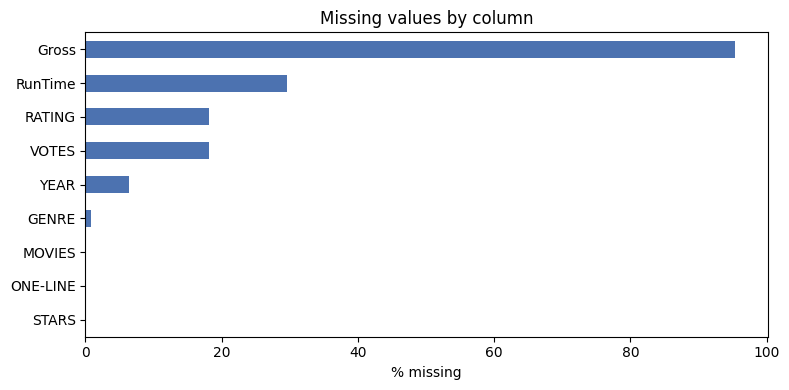

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
missing['missing_pct'].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Reading this:**
- `Gross` is missing for ~95% of rows. This is *not* random — IMDb only reports box-office gross
  for theatrically-released films, not TV series, miniseries, or shorts. This is **structurally
  missing data**, and imputing it (e.g. with the mean) would be actively misleading. We'll keep it
  as a numeric column with real NaNs rather than guessing values.
- `RunTime`, `RATING`, and `VOTES` are missing for a smaller but still meaningful chunk — often
  because the title is too new to have aggregated votes/ratings yet, or runtime wasn't listed.
- `YEAR` and `GENRE` have comparatively little missingness.

This already tells us our strategy: **don't apply one blanket missing-value rule to the whole
dataframe.** Each column's missingness has a different cause and needs a different response.

## 4. Audit duplicate rows

In [7]:
exact_dupes = df_raw.duplicated().sum()
title_dupes = df_raw.duplicated(subset=['MOVIES']).sum()
title_year_dupes = df_raw.duplicated(subset=['MOVIES', 'YEAR', 'ONE-LINE']).sum()

print(f"Fully identical rows:                       {exact_dupes}")
print(f"Rows with a repeated MOVIES title:           {title_dupes}")
print(f"Rows matching on MOVIES + YEAR + ONE-LINE:   {title_year_dupes}")


Fully identical rows:                       431
Rows with a repeated MOVIES title:           3182
Rows matching on MOVIES + YEAR + ONE-LINE:   849


**Reading this:** there's a real difference between these three numbers.

- `MOVIES` title repeats a lot (3,000+ rows) — but that's expected and **correct**: there are
  many real movies/shows that legitimately share a title (e.g. multiple films called "Annabelle"
  or remakes). This is *not* duplication, it's IMDb's own roman-numeral disambiguation
  (`(I)`, `(II)`, ...) doing its job.
- Rows matching on title **+** year **+** synopsis are almost certainly the *same listing*
  scraped twice — that's a much safer definition of "duplicate" to act on.
- Fully identical rows are unambiguous duplicates.

We'll drop the unambiguous duplicates later, after cleaning, using the title+year+synopsis
definition — not just the title.

## 5. Clean each column

We'll now build a working copy, `df`, and clean one column at a time. For each one we'll:
look at the raw mess → decide on a transformation → implement it → verify it worked.

In [8]:
df = df_raw.copy()


### 5.1 `MOVIES` — title

The simplest fix: strip leading/trailing whitespace. We keep the column name but overwrite
its contents.

In [9]:
df['MOVIES'] = df['MOVIES'].str.strip()
df['MOVIES'].head()


,MOVIES
0,Blood Red Sky
1,Masters of the Universe: Revelation
2,The Walking Dead
3,Rick and Morty
4,Army of Thieves


### 5.2 `YEAR` — split into `START_YEAR`, `END_YEAR`, `STATUS`

This is the most irregular column in the dataset. Raw values look like:

| Raw value | Meaning |
|---|---|
| `(2021)` | a movie released in 2021 |
| `(2021– )` | a TV series that started in 2021 and is still running |
| `(2010–2022)` | a TV series that ran from 2010 to 2022 |
| `(I) (2018– )` | a roman-numeral-disambiguated title, ongoing since 2018 |
| `(2017 TV Movie)` | a made-for-TV movie |
| `(III)` | only a disambiguator, **no year at all** |

A naive regex anchored to the *start* of the string (e.g. assuming the first characters are
always a year) breaks on the roman-numeral and "TV Movie" cases. The robust approach is:
**search for all 4-digit numbers anywhere in the string**, and separately check whether an
en-dash (`–`) is present to detect "ongoing" status. This sidesteps every formatting variant.

In [10]:
def parse_year(value):
    '''Extract (start_year, end_year, status) from a raw YEAR string.'''
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, 'Unknown'])

    years = re.findall(r'\d{4}', value)
    has_dash = '\u2013' in value  # en-dash, used by IMDb for ranges

    if not years:
        # e.g. "(III)" with no year information at all
        return pd.Series([np.nan, np.nan, 'Unknown'])

    if len(years) == 1:
        if has_dash:
            return pd.Series([int(years[0]), np.nan, 'Ongoing'])
        return pd.Series([int(years[0]), int(years[0]), 'Released'])

    # Two or more years found -> a started-and-ended range
    return pd.Series([int(years[0]), int(years[1]), 'Ended'])

df[['START_YEAR', 'END_YEAR', 'STATUS']] = df['YEAR'].apply(parse_year)
df[['YEAR', 'START_YEAR', 'END_YEAR', 'STATUS']].head(10)


,YEAR,START_YEAR,END_YEAR,STATUS
0,(2021),2021.0,2021.0,Released
1,(2021– ),2021.0,NaN,Ongoing
2,(2010–2022),2010.0,2022.0,Ended
3,(2013– ),2013.0,NaN,Ongoing
4,(2021),2021.0,2021.0,Released
5,(2020– ),2020.0,NaN,Ongoing
6,(2021),2021.0,2021.0,Released
7,(2006–2013),2006.0,2013.0,Ended
8,(2020– ),2020.0,NaN,Ongoing
9,(2019– ),2019.0,NaN,Ongoing


In [11]:
# Sanity-check the parser
print(df['STATUS'].value_counts(dropna=False))
print()
still_missing = df['START_YEAR'].isna() & df['YEAR'].notna()
print(f"YEAR values we genuinely could not parse a year from: {still_missing.sum()}")
print(df.loc[still_missing, 'YEAR'].unique()[:10])


STATUS
Released    4683
Ongoing     3180
Ended       1388
Unknown      748
Name: count, dtype: int64

YEAR values we genuinely could not parse a year from: 104
['(I)' '(III)' '(II)' '(XII)' '(VII)' '(IV)' '(V)' '(TV Special)'
 '(TV Movie)' '(VIII)']


Those remaining ~100 unparsed rows are genuinely just `(I)`, `(Video)`, `(TV Special)` with
**no year present in the source data at all** — not a parsing bug, but a real data gap. We leave
`START_YEAR`/`END_YEAR` as `NaN` for these rather than inventing a value.

### 5.3 `GENRE` — strip and split into a list

`GENRE` holds comma-separated values inside one messy string. We strip whitespace, then split
into a clean Python list per row — this is the standard representation for **multi-label**
categorical data, and makes later groupby/explode-based analysis trivial.

In [12]:
df['GENRE'] = df['GENRE'].str.strip()
df['GENRE_LIST'] = df['GENRE'].apply(
    lambda x: [g.strip() for g in x.split(',')] if pd.notna(x) else []
)
df[['GENRE', 'GENRE_LIST']].head()


,GENRE,GENRE_LIST
0,"Action, Horror, Thriller","[Action, Horror, Thriller]"
1,"Animation, Action, Adventure","[Animation, Action, Adventure]"
2,"Drama, Horror, Thriller","[Drama, Horror, Thriller]"
3,"Animation, Adventure, Comedy","[Animation, Adventure, Comedy]"
4,"Action, Crime, Horror","[Action, Crime, Horror]"


In [13]:
# Quick look at the genre vocabulary using explode — a useful pattern for list-columns
all_genres = df['GENRE_LIST'].explode().dropna()
print(f"Number of distinct genres: {all_genres.nunique()}")
all_genres.value_counts().head(10)


Number of distinct genres: 27


,count
GENRE_LIST,
Drama,4325
Comedy,2832
Action,2258
Adventure,1792
Animation,1732
Crime,1566
Documentary,1224
Thriller,910
Mystery,880


### 5.4 `RATING` — already numeric, just needs a documented strategy for missing values

`RATING` was parsed as `float64` by pandas already (no string formatting issues), so there's no
transformation needed. The only decision is what to do about the ~18% that are missing — covered
in the missing-value strategy section below. We deliberately do **not** impute it here, since a
guessed rating could mislead any downstream analysis.

In [14]:
df['RATING'].describe()


,RATING
count,8179.000000
mean,6.921176
std,1.220232
min,1.100000
25%,6.200000
50%,7.100000
75%,7.800000
max,9.900000


### 5.5 `ONE-LINE` — synopsis text

Same whitespace issue as `MOVIES` and `GENRE`. A simple strip is sufficient; we leave the
sentence content untouched since it's free text, not a structured field.

In [15]:
df['ONE-LINE'] = df['ONE-LINE'].str.strip()
df['ONE-LINE'].head(2)


,ONE-LINE
0,A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic...
1,The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series ...


### 5.6 `STARS` — split into `DIRECTOR` and `CAST`

This column packs two different pieces of information into one string, using `Director:` and
`Stars:` as inline labels — and the `Director:` label is **missing entirely** for TV series
(which credit different directors per episode, so IMDb doesn't list one). We use two separate
regex searches: one anchored on `Director:` (optional — may not match), one on `Stars:`.

In [16]:
def parse_stars(value):
    '''Pull (director, cast) out of the combined STARS blob.'''
    if pd.isna(value):
        return pd.Series([np.nan, np.nan])

    director_match = re.search(
        r'Directors?:\s*\n?(.+?)(?:\n\s*\|\s*\n|\n\s*Stars?:|$)', value, re.DOTALL
    )
    stars_match = re.search(r'Stars?:\s*\n?(.+)', value, re.DOTALL)

    director = director_match.group(1).replace('\n', '').strip() if director_match else np.nan
    cast = stars_match.group(1).replace('\n', '').strip() if stars_match else np.nan

    return pd.Series([director, cast])

df[['DIRECTOR', 'CAST']] = df['STARS'].apply(parse_stars)
df[['STARS', 'DIRECTOR', 'CAST']].head(6)


,STARS,DIRECTOR,CAST
0,"\n Director:\nPeter Thorwarth\n| \n Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Set...",Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti"
1,"\n \n Stars:\nChris Wood, \nSarah Michelle Gellar, \nLena Headey, \nMark Hamill\n",NaN,"Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill"
2,"\n \n Stars:\nAndrew Lincoln, \nNorman Reedus, \nMelissa McBride, \nLauren Cohan\n",NaN,"Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan"
3,"\n \n Stars:\nJustin Roiland, \nChris Parnell, \nSpencer Grammer, \nSarah Chalke\n",NaN,"Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke"
4,"\n Director:\nMatthias Schweighöfer\n| \n Stars:\nMatthias Schweighöfer, \nNathalie Emmanuel, \nRuby O. Fee, \...",Matthias Schweighöfer,"Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin"
5,"\n \n Stars:\nChase Stokes, \nMadelyn Cline, \nMadison Bailey, \nJonathan Daviss\n",NaN,"Chase Stokes, Madelyn Cline, Madison Bailey, Jonathan Daviss"


In [17]:
print(f"Rows with no director listed (expected for TV series): {df['DIRECTOR'].isna().sum()}")
print(f"Rows with no cast listed:                                   {df['CAST'].isna().sum()}")


Rows with no director listed (expected for TV series): 3646
Rows with no cast listed:                                   793


We could further split `CAST` into a list of individual actor names the same way we did for
`GENRE` — useful if you plan to do co-star network analysis later.

In [18]:
df['CAST_LIST'] = df['CAST'].apply(
    lambda x: [s.strip() for s in x.split(',')] if pd.notna(x) else []
)
df['CAST_LIST'].head(3)


,CAST_LIST
0,"[Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti]"
1,"[Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill]"
2,"[Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan]"


### 5.7 `VOTES` — remove thousands separators, convert to numeric

`VOTES` is stored as a comma-formatted string (`"21,062"`). `pd.to_numeric` can't parse that
directly, so we strip the commas first.

In [19]:
df['VOTES'] = df['VOTES'].str.replace(',', '', regex=False)
df['VOTES'] = pd.to_numeric(df['VOTES'], errors='coerce')
df['VOTES'].describe()


,VOTES
count,8.179000e+03
mean,1.512406e+04
std,7.005458e+04
min,5.000000e+00
25%,1.660000e+02
50%,7.890000e+02
75%,3.772000e+03
max,1.713028e+06


### 5.8 `RunTime` — already numeric; check for outliers

Pandas already parsed `RunTime` as a float. The remaining job is a sanity check: does the range
of values make sense for a runtime in minutes?

In [20]:
df['RunTime'].describe()


,RunTime
count,7041.000000
mean,68.688539
std,47.258056
min,1.000000
25%,36.000000
50%,60.000000
75%,95.000000
max,853.000000


In [21]:
# Anything above ~240 minutes (4 hours) for a single listing is worth a look —
# could be legitimate (a full TV season binned as one "runtime"), or could be bad data.
long_runtime = df[df['RunTime'] > 240][['MOVIES', 'YEAR', 'RunTime']]
print(f"Rows with RunTime > 240 minutes: {len(long_runtime)}")
long_runtime.head(10)


Rows with RunTime > 240 minutes: 65


,MOVIES,YEAR,RunTime
60,The Queen's Gambit,(2020),395.0
201,The Haunting of Hill House,(2018),572.0
207,El inocente,(2021),467.0
301,Behind Her Eyes,(2021),298.0
331,Unbelievable,(2019),385.0
347,Godless,(2017),452.0
352,The Haunting of Bly Manor,(2020),494.0
396,When They See Us,(2019),296.0
427,Maniac,(2018),386.0
439,The Stranger,(I) (2020),363.0


These long runtimes turn out to belong mostly to documentaries, anthology specials, and
multi-part TV events — plausible, not corrupted. We leave `RunTime` as-is rather than capping or
removing these values, since "fixing" real data based on a gut feeling would introduce a bias of
its own. (If your downstream task is sensitive to outliers, this is the point where you'd
document a deliberate capping/winsorizing strategy — but that's a modeling decision, not a
cleaning one.)

### 5.9 `Gross` — strip `$` / `M` and convert to numeric (millions)

Values look like `"$75.47M"`. We strip the formatting characters and convert to a float
representing **gross revenue in millions of USD**.

In [22]:
df['GROSS_MILLIONS'] = (
    df['Gross']
    .str.replace('$', '', regex=False)
    .str.replace('M', '', regex=False)
)
df['GROSS_MILLIONS'] = pd.to_numeric(df['GROSS_MILLIONS'], errors='coerce')
df['GROSS_MILLIONS'].describe()


,GROSS_MILLIONS
count,460.000000
mean,43.701870
std,82.423304
min,0.000000
25%,0.150000
50%,6.145000
75%,46.947500
max,504.010000


As noted in the missing-value audit, ~95% of rows are `NaN` here — and that's expected,
not an error, since most entries are TV content with no box-office figure to report.

## 6. Remove duplicate rows

Now that cleaning has normalized whitespace, we use the safer definition from Section 4:
rows that match on **title + year + synopsis** are true duplicate listings, not just
same-titled-different-works.

In [23]:
before = len(df)
df = df.drop_duplicates(subset=['MOVIES', 'YEAR', 'ONE-LINE']).reset_index(drop=True)
after = len(df)
print(f"Dropped {before - after} duplicate rows ({before} -> {after})")


Dropped 852 duplicate rows (9999 -> 9147)


## 7. Missing-value strategy — decide, don't default

Now that every column is in clean, structured form, we make an explicit, per-column decision
about missingness. The guiding principle: **only fill in a value if you have good reason to
believe what it should be; otherwise leave it as `NaN` and let downstream users/analyses decide
how to handle it.**

| Column | % missing | Decision | Reason |
|---|---|---|---|
| `RATING` | ~18% | **Leave as NaN** | No reliable way to guess a rating; imputing would bias any rating-based analysis. Flag and exclude per-analysis instead. |
| `VOTES` | ~18% | **Leave as NaN** | Missing alongside `RATING` (titles too new / unrated) — same reasoning. |
| `RunTime` | ~30% | **Leave as NaN** | Genuinely not listed for many entries; median-imputing runtime would distort any time-based analysis. |
| `GROSS_MILLIONS` | ~95% | **Leave as NaN, keep column** | Structurally missing (TV content has no box-office figure) — NaN *is* the correct, meaningful value here, not a gap to fill. |
| `START_YEAR` / `END_YEAR` | <10% | **Leave as NaN** | A genuine data gap in the source (~100 rows with no year at all). |
| `DIRECTOR` | ~37% | **Leave as NaN** | Structurally missing for TV series (multiple per-episode directors, not listed individually). |
| `GENRE` | <1% | **Leave as NaN** | Negligible; not worth a fill rule. |

Notice that **we don't drop any rows** for missingness — every missing value here is either
genuinely unknown or structurally not applicable, and dropping the row would throw away the rest
of that row's perfectly good information (title, genre, cast, etc.) just because one unrelated
field is blank. The right move is to leave NaNs in place and let each downstream analysis
explicitly filter on the columns it actually needs.

## 8. Assemble the final cleaned dataframe

Finally, we select and reorder the clean columns, dropping the original raw text fields that have
now been superseded by structured versions.

In [24]:
clean_columns = [
    'MOVIES', 'START_YEAR', 'END_YEAR', 'STATUS',
    'GENRE_LIST', 'RATING', 'VOTES', 'RunTime', 'GROSS_MILLIONS',
    'DIRECTOR', 'CAST_LIST', 'ONE-LINE'
]

df_clean = df[clean_columns].copy()
df_clean = df_clean.rename(columns={
    'MOVIES': 'title',
    'GENRE_LIST': 'genres',
    'RATING': 'rating',
    'VOTES': 'votes',
    'RunTime': 'runtime_minutes',
    'GROSS_MILLIONS': 'gross_millions_usd',
    'DIRECTOR': 'director',
    'CAST_LIST': 'cast',
    'ONE-LINE': 'synopsis',
})

df_clean.head()


,title,START_YEAR,END_YEAR,STATUS,genres,rating,votes,runtime_minutes,gross_millions_usd,director,cast,synopsis
0,Blood Red Sky,2021.0,2021.0,Released,"[Action, Horror, Thriller]",6.1,21062.0,121.0,NaN,Peter Thorwarth,"[Peri Baumeister, Carl Anton Koch, Alexander Scheer, Kais Setti]",A woman with a mysterious illness is forced into action when a group of terrorists attempt to hijack a transatlantic...
1,Masters of the Universe: Revelation,2021.0,NaN,Ongoing,"[Animation, Action, Adventure]",5.0,17870.0,25.0,NaN,NaN,"[Chris Wood, Sarah Michelle Gellar, Lena Headey, Mark Hamill]",The war for Eternia begins again in what may be the final battle between He-Man and Skeletor. A new animated series ...
2,The Walking Dead,2010.0,2022.0,Ended,"[Drama, Horror, Thriller]",8.2,885805.0,44.0,NaN,NaN,"[Andrew Lincoln, Norman Reedus, Melissa McBride, Lauren Cohan]",Sheriff Deputy Rick Grimes wakes up from a coma to learn the world is in ruins and must lead a group of survivors to...
3,Rick and Morty,2013.0,NaN,Ongoing,"[Animation, Adventure, Comedy]",9.2,414849.0,23.0,NaN,NaN,"[Justin Roiland, Chris Parnell, Spencer Grammer, Sarah Chalke]",An animated series that follows the exploits of a super scientist and his not-so-bright grandson.
4,Army of Thieves,2021.0,2021.0,Released,"[Action, Crime, Horror]",NaN,NaN,NaN,NaN,Matthias Schweighöfer,"[Matthias Schweighöfer, Nathalie Emmanuel, Ruby O. Fee, Stuart Martin]","A prequel, set before the events of Army of the Dead, which focuses on German safecracker Ludwig Dieter leading a gr..."


In [25]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9147 entries, 0 to 9146
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               9147 non-null   object 
 1   START_YEAR          8581 non-null   float64
 2   END_YEAR            5937 non-null   float64
 3   STATUS              9147 non-null   object 
 4   genres              9147 non-null   object 
 5   rating              7956 non-null   float64
 6   votes               7956 non-null   float64
 7   runtime_minutes     6933 non-null   float64
 8   gross_millions_usd  460 non-null    float64
 9   director            5835 non-null   object 
 10  cast                9147 non-null   object 
 11  synopsis            9147 non-null   object 
dtypes: float64(6), object(6)
memory usage: 857.7+ KB


## 9. Validate the cleaned dataset

A final pass of sanity checks before we trust this file for analysis.

In [26]:
checks = []

checks.append(("Row count preserved minus true duplicates",
                len(df_clean) == after))

checks.append(("rating is within IMDb's 1-10 scale",
                df_clean['rating'].dropna().between(1, 10).all()))

checks.append(("START_YEAR is within a sane historical range",
                df_clean['START_YEAR'].dropna().between(1900, 2026).all()))

checks.append(("votes is non-negative",
                (df_clean['votes'].dropna() >= 0).all()))

checks.append(("runtime_minutes is positive",
                (df_clean['runtime_minutes'].dropna() > 0).all()))

checks.append(("no duplicate (title, START_YEAR, synopsis) rows remain",
                df_clean.duplicated(subset=['title', 'START_YEAR', 'synopsis']).sum() == 0))

for description, passed in checks:
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {description}")


[PASS] Row count preserved minus true duplicates
[PASS] rating is within IMDb's 1-10 scale
[PASS] START_YEAR is within a sane historical range
[PASS] votes is non-negative
[PASS] runtime_minutes is positive
[PASS] no duplicate (title, START_YEAR, synopsis) rows remain


In [27]:
print("Before cleaning:", df_raw.shape)
print("After cleaning: ", df_clean.shape)
print()
print("Missing value % after cleaning:")
(df_clean.isna().mean() * 100).round(1)


Before cleaning: (9999, 9)
After cleaning:  (9147, 12)

Missing value % after cleaning:


,0
title,0.0
START_YEAR,6.2
END_YEAR,35.1
STATUS,0.0
genres,0.0
rating,13.0
votes,13.0
runtime_minutes,24.2
gross_millions_usd,95.0
director,36.2


## 10. A quick reward: explore the cleaned data

With clean, typed columns, basic exploratory plots that would have required messy string
parsing now take one line each.

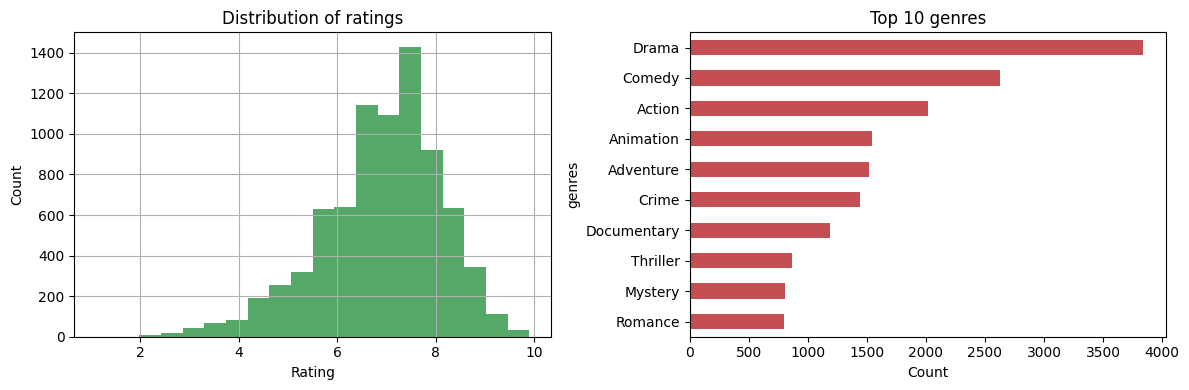

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clean['rating'].dropna().hist(bins=20, ax=axes[0], color='#55A868')
axes[0].set_title('Distribution of ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

top_genres = df_clean['genres'].explode().value_counts().head(10)
top_genres.sort_values().plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Top 10 genres')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


## 11. Export the cleaned dataset

`genres` and `cast` are list-valued columns, which CSV can't natively represent — we join them
into a delimited string on export (a common, simple convention) so the file stays a single flat
CSV. If you plan to keep working in pandas/Python only, exporting to `.pkl` or `.parquet` instead
would preserve the list types exactly.

In [29]:
df_export = df_clean.copy()
df_export['genres'] = df_export['genres'].apply(lambda x: '|'.join(x) if x else '')
df_export['cast'] = df_export['cast'].apply(lambda x: '|'.join(x) if x else '')

df_export.to_csv('movies_clean.csv', index=False)
print("Saved movies_clean.csv —", df_export.shape)


Saved movies_clean.csv — (9147, 12)


## Summary

What we did, and why each decision was made:

1. **Inspected before touching anything** — used `repr()` to see the *actual* raw strings, not
   the display-truncated version, which revealed the newline/whitespace problem immediately.
2. **Audited missingness and duplicates separately, by cause** — distinguished "same title used
   by two different works" from "the same listing scraped twice," and "structurally not
   applicable" (`Gross` for TV shows) from "genuinely unknown" (`RATING` for unreleased titles).
3. **Cleaned column-by-column with regex**, building each transformation incrementally and
   verifying it against edge cases (roman numerals, "TV Movie" tags, missing `Director:` labels)
   rather than assuming one pattern fits every row.
4. **Made an explicit, written decision per column** about missing data instead of applying a
   single blanket rule — and chose to preserve rows with partial missingness rather than drop
   them, since most missingness here is meaningful, not noise.
5. **Validated the result** with concrete sanity checks (rating bounds, year bounds, no remaining
   duplicates) rather than assuming the cleaning worked.

The general pattern — *inspect → understand each column's specific dirtiness → transform →
decide on missingness explicitly → validate* — applies well beyond this dataset.
